In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
movies = pd.read_csv("/Users/alexgarcia/Desktop/CityUniversity/MSDS/DS522 Data Aquisition and Analytics/Modules/Module7/PE07/movies.csv")
ratings = pd.read_excel("/Users/alexgarcia/Desktop/CityUniversity/MSDS/DS522 Data Aquisition and Analytics/Modules/Module7/PE07/ratings.xlsx")

print("movies:", movies.shape)
print("ratings:", ratings.shape)
movies.head()

movies: (9742, 3)
ratings: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
inner_merged = pd.merge(ratings, movies, on="movieId", how="inner")
left_merged  = pd.merge(ratings, movies, on="movieId", how="left")
right_merged = pd.merge(ratings, movies, on="movieId", how="right")
outer_merged = pd.merge(ratings, movies, on="movieId", how="outer")

print(f"inner: {inner_merged.shape}")
print(f"left : {left_merged.shape}")
print(f"right: {right_merged.shape}")
print(f"outer: {outer_merged.shape}")

inner: (100836, 6)
left : (100836, 6)
right: (100854, 6)
outer: (100854, 6)


In [9]:
inner_merged.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [10]:
# np.digitize — bin edges [1, 2, 3, 4, 5] → bin numbers 0..5
ratings["digitized_rating"] = np.digitize(ratings["rating"], bins=[1, 2, 3, 4, 5])

# pd.cut — named intervals
ratings["cut_rating"] = pd.cut(
    ratings["rating"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True,
)

# pd.qcut — quartiles
ratings["qcut_rating"] = pd.qcut(
    ratings["rating"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

ratings.head(10)

,userId,movieId,rating,timestamp,digitized_rating,cut_rating,qcut_rating
0,1,1,4.0,964982703,4,High,Q3
1,1,3,4.0,964981247,4,High,Q3
2,1,6,4.0,964982224,4,High,Q3
3,1,47,5.0,964983815,5,Very High,Q4
4,1,50,5.0,964982931,5,Very High,Q4
5,1,70,3.0,964982400,3,Medium,Q1
6,1,101,5.0,964980868,5,Very High,Q4
7,1,110,4.0,964982176,4,High,Q3
8,1,151,5.0,964984041,5,Very High,Q4
9,1,157,5.0,964984100,5,Very High,Q4


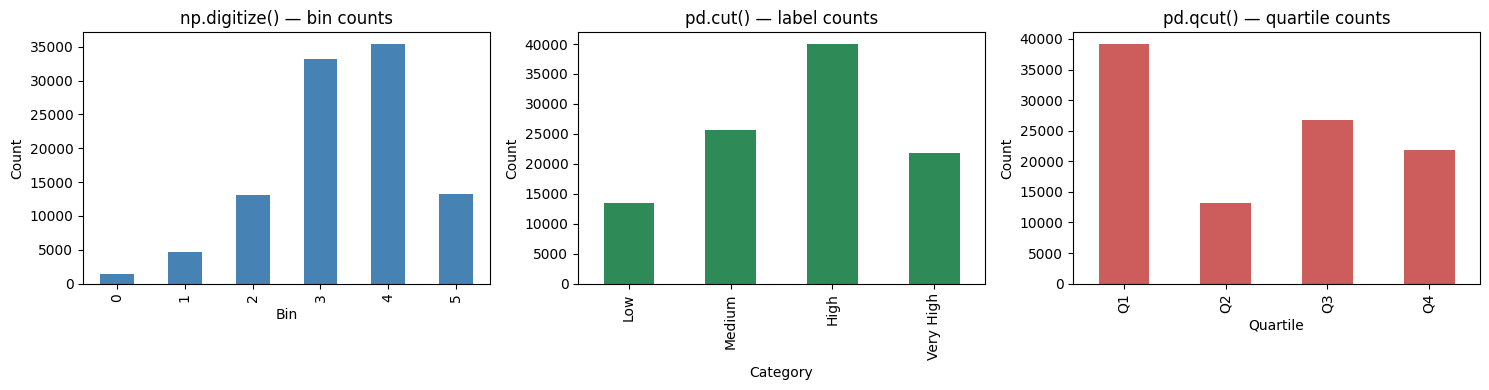

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ratings["digitized_rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("np.digitize() — bin counts")
axes[0].set_xlabel("Bin"); axes[0].set_ylabel("Count")

ratings["cut_rating"].value_counts().reindex(["Low", "Medium", "High", "Very High"]).plot(
    kind="bar", ax=axes[1], color="seagreen"
)
axes[1].set_title("pd.cut() — label counts")
axes[1].set_xlabel("Category"); axes[1].set_ylabel("Count")

ratings["qcut_rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="indianred"
)
axes[2].set_title("pd.qcut() — quartile counts")
axes[2].set_xlabel("Quartile"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [12]:
print("Missing in outer_merged:")
print(outer_merged.isna().sum())

Missing in outer_merged:
userId       18
movieId       0
rating       18
timestamp    18
title         0
genres        0
dtype: int64


In [13]:
# Strategy A: fill numeric NaNs with 0, fill text NaNs with "Unknown"
filled_zero = outer_merged.copy()
num_cols = filled_zero.select_dtypes(include=[np.number]).columns
filled_zero[num_cols] = filled_zero[num_cols].fillna(0)
filled_zero["title"]  = filled_zero["title"].fillna("Unknown")
filled_zero["genres"] = filled_zero["genres"].fillna("Unknown")

# Strategy B: mean for numeric, mode for categorical
filled_stats = outer_merged.copy()
filled_stats["rating"]    = filled_stats["rating"].fillna(filled_stats["rating"].mean())
filled_stats["userId"]    = filled_stats["userId"].fillna(filled_stats["userId"].mode()[0])
filled_stats["timestamp"] = filled_stats["timestamp"].fillna(filled_stats["timestamp"].mean())
filled_stats["title"]     = filled_stats["title"].fillna(filled_stats["title"].mode()[0])
filled_stats["genres"]    = filled_stats["genres"].fillna(filled_stats["genres"].mode()[0])

print("After zero-fill:", filled_zero.isna().sum().sum(), "NaNs remaining")
print("After mean/mode:", filled_stats.isna().sum().sum(), "NaNs remaining")
filled_stats.head()

After zero-fill: 0 NaNs remaining
After mean/mode: 0 NaNs remaining


,userId,movieId,rating,timestamp,title,genres
0,1.0,1,4.0,9.649827e+08,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5.0,1,4.0,8.474350e+08,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7.0,1,4.5,1.106636e+09,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15.0,1,2.5,1.510578e+09,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17.0,1,4.5,1.305696e+09,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


In [14]:
wide_ratings = ratings.pivot_table(
    index="userId", columns="movieId", values="rating", aggfunc="mean"
)
print("wide:", wide_ratings.shape)
wide_ratings.head()

wide: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Stack long format (userId, movieId, rating)
stacked_ratings = wide_ratings.stack().reset_index(name="rating")
print("stacked (long):", stacked_ratings.shape)
stacked_ratings.head()

stacked (long): (5931640, 3)


,userId,movieId,rating
0,1,1,4.0
1,1,2,NaN
2,1,3,4.0
3,1,4,NaN
4,1,5,NaN


In [ ]:
# Unstack restore wide format
unstacked_ratings = stacked_ratings.set_index(["userId", "movieId"])["rating"].unstack()
print("unstacked (wide):", unstacked_ratings.shape)
unstacked_ratings.head()

unstacked (wide): (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
ratings_with_genres = pd.merge(ratings, movies, on="movieId", how="inner")
ratings_with_genres["genre"] = ratings_with_genres["genres"].str.split("|")
exploded = ratings_with_genres.explode("genre")

genre_counts = (
    exploded.groupby("genre")
            .size()
            .reset_index(name="num_ratings")
            .sort_values("num_ratings", ascending=False)
            .reset_index(drop=True)
)
genre_counts

,genre,num_ratings
0,Drama,41928
1,Comedy,39053
2,Action,30635
3,Thriller,26452
4,Adventure,24161
5,Romance,18124
6,Sci-Fi,17243
7,Crime,16681
8,Fantasy,11834
9,Children,9208


In [19]:
most_rated_genre = genre_counts.iloc[0]["genre"]
print(f"Most-rated genre: {most_rated_genre} "
      f"({genre_counts.iloc[0]['num_ratings']} ratings)")

Most-rated genre: Drama (41928 ratings)


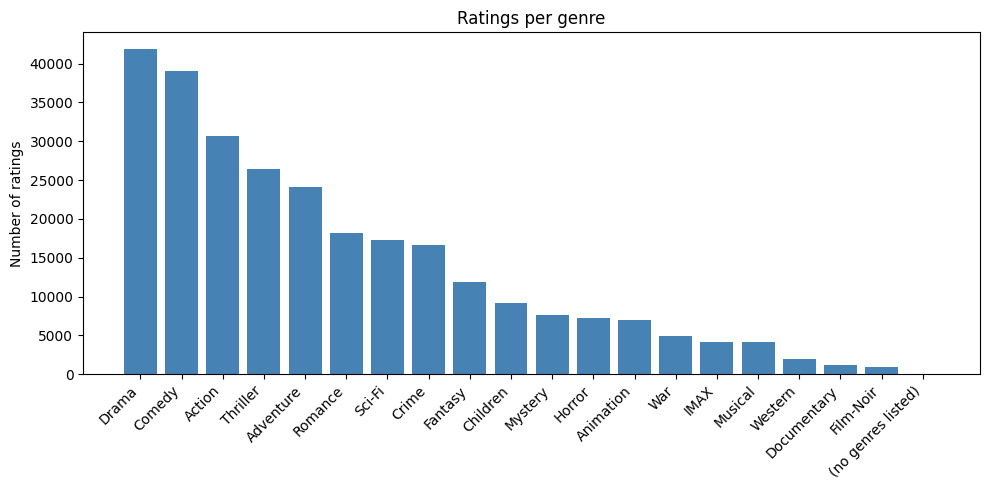

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(genre_counts["genre"], genre_counts["num_ratings"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of ratings")
plt.title("Ratings per genre")
plt.tight_layout()
plt.show()